# Phase 1: Data Preparation & Feature Engineering
## Predicting Student Dropout Before It Happens: AI for EdTech Retention

---

### What this notebook does

This is the **foundation notebook** for our entire analysis. It takes the raw dataset of ~18,700 students from online programming bootcamps and transforms it into four clean, analysis-ready datasets, one for each **dropout checkpoint** in the course.

**What it consumes:** `Bayes 26D.csv`, the raw, harmonised dataset spanning ~5 years of cohorts across multiple UK universities.

**What it produces:**
- `data/processed/cohort_1.parquet` through `cohort_4.parquet`: four cohort datasets with engineered features and survival targets
- `data/processed/cohort_1_noeng.parquet` through `cohort_4_noeng.parquet`: the same four cohorts but with engagement features removed (for comparison in Phase 2)
- A data-quality summary table saved to `outputs/tables/`

### Why this structure?

We reframed what looks like a simple "will this student drop out?" question into a **survival analysis problem**. Students don't just vanish randomly; they leave at structured checkpoints, typically after each test. By splitting the data at these natural exit points, we create four separate prediction problems, each with its own dataset. This is methodologically superior to building one big model on the whole dataset, because it eliminates the need to impute missing data (a practice that would introduce bias; see Section 1.2).

### Key methodological commitments
- **No imputation** of any kind. Missing values mean the student has left; they are exits, not errors.
- **Reproducibility:** All random operations use seed `42`.
- Every code cell is preceded by a plain-English explanation of what it does and why.

## 1.0: Environment Setup

We begin by importing the libraries we'll use throughout this notebook. Everything here is standard Python data-science tooling:

- **pandas**: our primary tool for tabular data manipulation
- **numpy**: numerical operations
- **matplotlib & seaborn**: data visualisation
- **pathlib**: clean, cross-platform file path handling
- **os**: for creating directories if they don't yet exist

In [1]:
# ──────────────────────────────────────────────
# Imports
# ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings

# Suppress minor warnings for cleaner notebook output
warnings.filterwarnings('ignore', category=FutureWarning)

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)

# ── Project directory structure ──
# Phase 1 writes processed data; Phases 2 & 3 read it.
PROCESSED_DIR = Path('data/processed')
FIGURES_DIR   = Path('outputs/figures')
TABLES_DIR    = Path('outputs/tables')
MODELS_DIR    = Path('models')

for d in [PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Plot styling ──
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

print("✓ Environment ready. Random seed:", SEED)

✓ Environment ready. Random seed: 42


---
## 1.1: Load and Inspect the Raw Data

We load the CSV file with its first column used as the row index (it's just a row ID, not a feature). After loading, we expect exactly **18,724 rows** (students) and **18 columns** (features + target).

The 18 columns fall into five logical groups, reflecting the chronological structure of the course:

| Group | Columns | Description |
|---|---|---|
| **Demographics** | `External`, `Year` | Background info available at enrolment |
| **Session attendance** | `session 1`–`session 6` | % of each live Zoom lecture the student watched (0–100) |
| **Test grades** | `test 1`, `test 2`, `test 3` | Letter grades (A–F) on the three course tests |
| **Coursework grades** | `ind cw`, `group cw`, `final grade` | Letter grades for coursework and the overall course |
| **Engagement** | `forum Q`, `forum A`, `office hour visits` | Cumulative counts of participation throughout the course |
| **Target** | `dropout` | Whether the student dropped out (`Y`) or completed (`N`) |

The columns follow the course's chronological order: sessions 1–2 happen before Test 1, sessions 3–4 before Test 2, and so on. This ordering will be critical when we build our cohorts.

In [2]:
# ──────────────────────────────────────────────
# Load the raw dataset
# ──────────────────────────────────────────────
df = pd.read_csv('Bayes 26D.csv', index_col=0)

# Validate shape: we expect exactly 18,724 students and 18 columns
assert df.shape == (18724, 18), (
    f"Unexpected shape {df.shape}, expected (18724, 18). "
    "Check that the first CSV column is being used as the index."
)
print(f"✓ Dataset loaded: {df.shape[0]:,} students × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")

✓ Dataset loaded: 18,724 students × 18 columns

Column names:
['External', 'Year', 'session 1', 'session 2', 'test 1', 'session 3', 'session 4', 'test 2', 'session 5', 'test 3', 'session 6', 'ind cw', 'group cw', 'final grade', 'forum Q', 'forum A', 'office hour visits', 'dropout']


In [3]:
# Quick look at the first few rows to confirm structure
df.head()

,External,Year,session 1,session 2,test 1,session 3,session 4,test 2,session 5,test 3,session 6,ind cw,group cw,final grade,forum Q,forum A,office hour visits,dropout
0,N,third,9,1,F,29.0,42.0,D,75.0,C,75.0,D,C,C,3,5,5,N
1,N,third,14,37,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1,0,Y
2,N,third,43,4,A,95.0,18.0,B,75.0,D,46.0,F,C,A,18,20,5,Y
3,N,second,4,4,A,10.0,29.0,A,45.0,D,21.0,A,D,A,0,2,2,N
4,N,third,55,85,F,35.0,88.0,F,NaN,NaN,NaN,NaN,NaN,NaN,11,5,3,Y


In [4]:
# Data types: note that session columns are float (because NaN forces int → float),
# grades and demographics are objects (strings), engagement columns are integers
df.dtypes

External               object
Year                   object
session 1               int64
session 2               int64
test 1                 object
session 3             float64
session 4             float64
test 2                 object
session 5             float64
test 3                 object
session 6             float64
ind cw                 object
group cw               object
final grade            object
forum Q                 int64
forum A                 int64
office hour visits      int64
dropout                object
dtype: object

---
## 1.2: Understanding the Missing Values (The Most Important Insight)

This is the single most important fact in the entire project:

> **Missing values in this dataset are not errors. They are exits.**

When a student's data stops (say they have values for `session 1`, `session 2`, and `test 1`, but everything from `session 3` onwards is `NaN`), that means the student **dropped out after Test 1**. They never attended sessions 3–6, never took tests 2 or 3, and never submitted coursework. Those cells aren't missing because someone forgot to record them; they're missing because those events never happened for that student.

This is called **monotone missingness**: once a student's data ends, *every* subsequent column is also empty. The missingness increases step by step as we move through the chronological columns.

### Why this rules out imputation

Standard data science practice when faced with missing data is **imputation**: filling in the blanks with estimates (the column mean, median, or predictions from other features). In our case, this would be **methodologically wrong**:

- Imputing a `test 2` grade for a student who dropped out after Test 1 means inventing a grade for an exam they never sat
- We ruled this out early: imputing would mean inventing outcomes for events that never happened, and it risks introducing systematic bias into the analysis
- Our cohort-based approach (Section 1.4 onwards) makes imputation unnecessary: by splitting students at each dropout checkpoint, we ensure **zero missing values** within every cohort dataset

In [5]:
# ──────────────────────────────────────────────
# Missing-value counts per column (chronological order)
# ──────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print("Missing values per column (ordered as they appear in the course):\n")
print(missing_summary.to_string())

Missing values per column (ordered as they appear in the course):

                    Missing Count  Missing %
External                        0        0.0
Year                            0        0.0
session 1                       0        0.0
session 2                       0        0.0
test 1                          0        0.0
session 3                    1212        6.5
session 4                    1212        6.5
test 2                       1212        6.5
session 5                    3517       18.8
test 3                       3517       18.8
session 6                    5092       27.2
ind cw                       5092       27.2
group cw                     5092       27.2
final grade                  5092       27.2
forum Q                         0        0.0
forum A                         0        0.0
office hour visits              0        0.0
dropout                         0        0.0


### Interpreting the pattern above

Notice how missingness only ever **increases** as we move through the chronological columns:

- `External`, `Year`, `session 1`, `session 2`, `test 1`: **zero** missing. Every student has these; they are the earliest data points.
- `session 3`, `session 4`, `test 2`: **1,212 missing**. These are the students who left after Test 1.
- `session 5`, `test 3`: **3,517 missing** (= 1,212 who left after Test 1 + 2,305 who left after Test 2).
- `session 6`, `ind cw`, `group cw`, `final grade`: **5,092 missing** (= 1,212 + 2,305 + 1,575 who left after Test 3).

The engagement columns (`forum Q`, `forum A`, `office hour visits`) and `dropout` have **zero** missing values because they are cumulative totals recorded for all students, regardless of when they left.

This monotone pattern is exactly what we'd expect from a course with structured dropout checkpoints. We'll now verify the exact counts.

---
## 1.3: Determining Each Student's Exit Point (Lifespan)

Before we can build our cohorts, we need to know **where** each student dropped out. We call this their **lifespan**: the number of dropout checkpoints they survived through.

The course has four checkpoints, so every student has a lifespan between 1 and 4:

| Lifespan | Meaning | How we detect it | Expected count |
|---|---|---|---|
| **1** | Left after Test 1 | `session 3` is missing | 1,212 |
| **2** | Left after Test 2 | Has `test 2` data, but `session 5` is missing | 2,305 |
| **3** | Left after Test 3 | Has `test 3` data, but `session 6` is missing | 1,575 |
| **4** | Reached the end | `final grade` is present | 13,632 |

A **lifespan** value tells us two things:
1. Which cohorts this student belongs to (a lifespan-2 student is in Cohorts 1 and 2 but not 3 or 4)
2. How to amortise their engagement features (Section 1.6)

We'll add this as a new column and validate against the expected counts.

In [6]:
# ──────────────────────────────────────────────
# Derive lifespan: how many cohorts each student participated in
# ──────────────────────────────────────────────
def assign_lifespan(row):
    """
    Determine the student's lifespan (1–4) based on where their data ends.
    
    Lifespan 1: dropped after Test 1 → session 3 is missing
    Lifespan 2: dropped after Test 2 → has session 3 but session 5 is missing
    Lifespan 3: dropped after Test 3 → has session 5 but session 6 is missing
    Lifespan 4: reached the end     → final grade is present
    """
    if pd.isna(row['session 3']):
        return 1
    elif pd.isna(row['session 5']):
        return 2
    elif pd.isna(row['session 6']):
        return 3
    else:
        return 4

df['lifespan'] = df.apply(assign_lifespan, axis=1)

# ── Validate against ground-truth counts ──
lifespan_counts = df['lifespan'].value_counts().sort_index()

EXPECTED_LIFESPANS = {1: 1212, 2: 2305, 3: 1575, 4: 13632}

print("Lifespan distribution:\n")
for ls in sorted(EXPECTED_LIFESPANS.keys()):
    actual = lifespan_counts[ls]
    expected = EXPECTED_LIFESPANS[ls]
    status = "✓" if actual == expected else "✗ MISMATCH"
    print(f"  Lifespan {ls}: {actual:>6,}  (expected {expected:>6,})  {status}")

print(f"\n  Total:     {lifespan_counts.sum():>6,}")

# Hard assertion: stop the notebook if counts are wrong
for ls, expected in EXPECTED_LIFESPANS.items():
    assert lifespan_counts[ls] == expected, (
        f"Lifespan {ls}: got {lifespan_counts[ls]}, expected {expected}"
    )
print("\n✓ All lifespan counts match expected values.")

Lifespan distribution:

  Lifespan 1:  1,212  (expected  1,212)  ✓
  Lifespan 2:  2,305  (expected  2,305)  ✓
  Lifespan 3:  1,575  (expected  1,575)  ✓
  Lifespan 4: 13,632  (expected 13,632)  ✓

  Total:     18,724

✓ All lifespan counts match expected values.


### Sanity check: total dropouts

The students who dropped out at any point are those with lifespans 1, 2, or 3 (they left before finishing), **plus** the "administrative dropouts" in lifespan 4 who completed the course but are still labelled `dropout = Y`. The total number of `dropout = Y` students in the raw data should be **7,547** (about 40.3% of all students).

In [7]:
# ──────────────────────────────────────────────
# Validate total dropout count
# ──────────────────────────────────────────────
total_dropout = (df['dropout'] == 'Y').sum()
total_students = len(df)

print(f"Total students:     {total_students:,}")
print(f"Total dropout = Y:  {total_dropout:,}")
print(f"Overall dropout rate: {total_dropout / total_students * 100:.1f}%")

assert total_dropout == 7547, f"Expected 7,547 dropouts, got {total_dropout}"
print("\n✓ Dropout count matches: 7,547 students (40.3%)")

Total students:     18,724
Total dropout = Y:  7,547
Overall dropout rate: 40.3%

✓ Dropout count matches: 7,547 students (40.3%)


---
## 1.4: Encoding Categorical Variables

Before we split the data into cohorts, we convert categorical columns into numbers. We do this **once on the full dataset** so that all four cohorts share identical, consistent encodings.

### Why ordinal encoding (not one-hot)?

The grade columns (`test 1`, `test 2`, etc.) have a **natural order**: A > B > C > D > F. This isn't arbitrary: an A genuinely represents better performance than a B, which is better than a C, and so on. **Ordinal encoding** (A=4, B=3, C=2, D=1, F=0) preserves this ordering, which both tree-based models and linear models can exploit.

The alternative, **one-hot encoding**, would create five separate columns per grade (e.g., `test1_A`, `test1_B`, …), treating them as unrelated categories and discarding the ordering information. This would inflate the feature count and lose a meaningful signal.

Similarly, `Year` (first/second/third) has a natural order (academic progression) and `External` (Y/N) is naturally binary.

### What we encode

| Column(s) | Encoding | Mapping |
|---|---|---|
| All grade columns | Ordinal | A=4, B=3, C=2, D=1, F=0 |
| `Year` | Ordinal | first=1, second=2, third=3 |
| `External` | Binary | Y=1, N=0 |
| `dropout` | **Not encoded**, kept as-is | Used only to derive Cohort 4's target, then dropped |

> **Important:** Grade columns that are `NaN` (because the student dropped out before that test) stay as `NaN` during encoding. We do **not** fill them in; they will naturally disappear when we build the cohorts, because a student who dropped before Test 2 simply won't appear in Cohort 2's dataset.

In [8]:
# ──────────────────────────────────────────────
# Encode categorical variables
# ──────────────────────────────────────────────

# Grade encoding: A=4, B=3, C=2, D=1, F=0
GRADE_MAP = {'A': 4, 'B': 3, 'C': 2, 'D': 1, 'F': 0}
GRADE_COLS = ['test 1', 'test 2', 'test 3', 'ind cw', 'group cw', 'final grade']

for col in GRADE_COLS:
    df[col] = df[col].map(GRADE_MAP)
    # NaN values are preserved by .map(): students who never took this assessment
    # still show NaN, which is correct

# Year encoding: first=1, second=2, third=3
YEAR_MAP = {'first': 1, 'second': 2, 'third': 3}
df['Year'] = df['Year'].map(YEAR_MAP)

# External encoding: Y=1, N=0
EXTERNAL_MAP = {'Y': 1, 'N': 0}
df['External'] = df['External'].map(EXTERNAL_MAP)

# Note: 'dropout' stays as 'Y'/'N' for now; it is NOT a feature
# It will only be used to create Cohort 4's survival target

# ── Verify encodings ──
print("Encoded dtypes:\n")
print(df[['External', 'Year', 'test 1', 'dropout']].dtypes)
print("\nSample of encoded values:")
df[['External', 'Year', 'session 1', 'test 1', 'forum Q', 'dropout']].head(8)

Encoded dtypes:

External     int64
Year         int64
test 1       int64
dropout     object
dtype: object

Sample of encoded values:


,External,Year,session 1,test 1,forum Q,dropout
0,0,3,9,0,3,N
1,0,3,14,0,3,Y
2,0,3,43,4,18,Y
3,0,2,4,4,0,N
4,0,3,55,0,11,Y
5,1,2,60,4,12,Y
6,1,1,26,1,2,Y
7,1,1,54,0,6,Y


---
## 1.5: Defining the Feature Blocks

The course progresses through a fixed sequence, and so do our features. We organise them into **blocks** that correspond to the course structure:

```
[Demographics]  ─── always available
[Block A]       ─── session 1, session 2, test 1         → available from Cohort 1
[Block B]       ─── session 3, session 4, test 2         → available from Cohort 2
[Block C]       ─── session 5, test 3                    → available from Cohort 3
[Block D]       ─── session 6, ind cw, group cw,         → available from Cohort 4
                     final grade
[Engagement]    ─── forum Q, forum A, office hour visits  → amortised share in each cohort
```

Each cohort includes all blocks up to and including its checkpoint, plus demographics and the amortised engagement share for that cohort. Crucially, **later blocks are dropped**: a Cohort 1 model cannot see test 2 grades because those exams haven't happened yet.

This is how we build the cohort-specific feature sets in code.

In [9]:
# ──────────────────────────────────────────────
# Define feature blocks
# ──────────────────────────────────────────────

DEMOGRAPHICS = ['External', 'Year']

BLOCK_A = ['session 1', 'session 2', 'test 1']       # Through Test 1
BLOCK_B = ['session 3', 'session 4', 'test 2']       # Through Test 2
BLOCK_C = ['session 5', 'test 3']                     # Through Test 3
BLOCK_D = ['session 6', 'ind cw', 'group cw', 'final grade']  # Final stage

ENGAGEMENT_COLS = ['forum Q', 'forum A', 'office hour visits']

# Which feature columns each cohort includes (cumulative)
COHORT_FEATURE_BLOCKS = {
    1: DEMOGRAPHICS + BLOCK_A,
    2: DEMOGRAPHICS + BLOCK_A + BLOCK_B,
    3: DEMOGRAPHICS + BLOCK_A + BLOCK_B + BLOCK_C,
    4: DEMOGRAPHICS + BLOCK_A + BLOCK_B + BLOCK_C + BLOCK_D,
}

print("Feature blocks defined:")
for cohort_num, cols in COHORT_FEATURE_BLOCKS.items():
    print(f"  Cohort {cohort_num}: {len(cols)} structured features + 3 engagement = {len(cols) + 3} total")

Feature blocks defined:
  Cohort 1: 5 structured features + 3 engagement = 8 total
  Cohort 2: 8 structured features + 3 engagement = 11 total
  Cohort 3: 10 structured features + 3 engagement = 13 total
  Cohort 4: 14 structured features + 3 engagement = 17 total


---
## 1.6: Amortising the Engagement Features

### The problem

Three columns, `forum Q` (questions posted), `forum A` (answers posted), and `office hour visits`, record **cumulative totals** across the student's entire time in the course. Critically, we have **no timestamps** telling us *when* these interactions occurred.

This creates a dilemma: if a student asked 16 forum questions total, we don't know whether they asked all 16 before Test 1 or spread them out over the whole course. Simply dumping the full total into Cohort 1 would be misleading: we'd be attributing activity to a time period when it may not have happened.

### The solution: uniform amortisation

**Amortisation** (from finance: spreading a cost evenly over a period) is the approach we settled on. We assume each student's engagement was distributed **uniformly** across the cohorts they were active in, then reveal a growing cumulative share in each successive cohort.

The formula for a student with **lifespan k** (they participated in k cohorts), showing the value in **cohort j**:

> **amortised value in cohort j = total ÷ k × j**

### Worked example 1: A student who completes all 4 cohorts (k=4) with 16 forum questions

| Cohort | Calculation | Shown value |
|---|---|---|
| 1 | 16 ÷ 4 × 1 | **4** |
| 2 | 16 ÷ 4 × 2 | **8** |
| 3 | 16 ÷ 4 × 3 | **12** |
| 4 | 16 ÷ 4 × 4 | **16** (full amount) |

### Worked example 2: A student who left after Test 2 (k=2) with 16 forum questions

| Cohort | Calculation | Shown value |
|---|---|---|
| 1 | 16 ÷ 2 × 1 | **8** |
| 2 | 16 ÷ 2 × 2 | **16** (full amount, this is their final cohort) |

### An honest caveat about target leakage

There is a subtle issue here worth acknowledging. Because the denominator **k** depends on the student's full lifespan, the amortised value in early cohorts mildly encodes *how long the student will ultimately stay*. A Cohort-1 dropout (k=1) gets their entire engagement total at once, while a long-surviving student (k=4) shows only a quarter. This means the amortised value partly reflects the target we're trying to predict: a mild form of **target leakage**.

We're using this method knowingly, as the best available approach without timestamp data. To be rigorous, we will produce **two variants** of each cohort:
1. **With amortised engagement**: includes the scaled engagement features
2. **Without engagement**: drops the three engagement columns entirely

Phase 2 will train models on both variants and compare, letting us quantify whether the amortised engagement helps or hurts prediction.

---
## 1.7: Building the Four Cohorts

Now we bring everything together. For each cohort, we:

1. **Select the right students**: only those whose lifespan is ≥ the cohort number (they hadn't dropped out yet)
2. **Select the right features**: demographics + all feature blocks up to this checkpoint + amortised engagement
3. **Engineer the survival target**: a binary column indicating whether this student survived to the next checkpoint
4. **Validate**: confirm zero missing values and correct student/target counts

Here is what each cohort looks like:

| Cohort | Who's included | Features available | Target column | Expected split |
|---|---|---|---|---|
| **1** | All 18,724 students | Demographics + Block A + engagement | `survives_phase_1` | 17,512 survive / 1,212 drop |
| **2** | 17,512 survivors of Cohort 1 | + Block B | `survives_phase_2` | 15,207 survive / 2,305 drop |
| **3** | 15,207 survivors of Cohort 2 | + Block C | `survives_phase_3` | 13,632 survive / 1,575 drop |
| **4** | 13,632 survivors of Cohort 3 | + all Blocks (A–D) | `survives_to_certificate` | 11,177 survive / 2,455 drop |

Notice the pattern here: as we move through cohorts, we have **fewer students but more features**. Early cohorts give us statistical power (many samples); late cohorts give us richer behavioural profiles.

We'll implement this with a single reusable function to keep the logic consistent and avoid copy-paste errors.

In [10]:
# ──────────────────────────────────────────────
# Cohort builder function
# ──────────────────────────────────────────────

def build_cohort(df, cohort_num, feature_cols, engagement_cols, 
                 target_name, min_lifespan, survive_condition):
    """
    Build one cohort dataset from the full encoded dataframe.
    
    Parameters
    ----------
    df : pd.DataFrame
        The full encoded dataset (with 'lifespan' column).
    cohort_num : int
        Which cohort this is (1–4), used for amortisation scaling.
    feature_cols : list[str]
        The structural feature columns for this cohort (demographics + blocks).
    engagement_cols : list[str]
        The three engagement columns to amortise.
    target_name : str
        Name of the engineered survival target column.
    min_lifespan : int
        Minimum lifespan to be included in this cohort.
    survive_condition : callable
        A function (row → bool) that returns True if the student survives
        this checkpoint, False if they drop here.
    
    Returns
    -------
    cohort_with_eng : pd.DataFrame
        Cohort dataset WITH amortised engagement features + target.
    cohort_no_eng : pd.DataFrame
        Cohort dataset WITHOUT engagement features + target.
    """
    # 1. Filter to students in this cohort
    cohort_df = df[df['lifespan'] >= min_lifespan].copy()
    
    # 2. Select structural features
    cohort_features = cohort_df[feature_cols].copy()
    
    # 3. Amortise engagement: total ÷ k × j
    #    where k = student's lifespan, j = this cohort number
    for col in engagement_cols:
        cohort_features[col] = (
            cohort_df[col] / cohort_df['lifespan'] * cohort_num
        )
    
    # 4. Engineer the survival target
    cohort_features[target_name] = cohort_df.apply(survive_condition, axis=1).astype(int)
    
    # 5. Build the engagement-dropped variant
    cohort_no_eng = cohort_features.drop(columns=engagement_cols)
    
    # 6. Validate: ZERO missing values allowed
    assert cohort_features.isnull().sum().sum() == 0, (
        f"Cohort {cohort_num} WITH engagement has missing values!\n"
        f"{cohort_features.isnull().sum()[cohort_features.isnull().sum() > 0]}"
    )
    assert cohort_no_eng.isnull().sum().sum() == 0, (
        f"Cohort {cohort_num} WITHOUT engagement has missing values!"
    )
    
    return cohort_features, cohort_no_eng

Now we call this function four times, once per cohort, with the specific rules for each checkpoint. After building each one, we validate that the student count and target balance match our expected ground-truth numbers.

In [11]:
# ──────────────────────────────────────────────
# Build all four cohorts
# ──────────────────────────────────────────────

# Expected ground-truth values for validation
EXPECTED = {
    1: {'n': 18724, 'survive': 17512, 'drop': 1212},
    2: {'n': 17512, 'survive': 15207, 'drop': 2305},
    3: {'n': 15207, 'survive': 13632, 'drop': 1575},
    4: {'n': 13632, 'survive': 11177, 'drop': 2455},
}

# ── Cohort 1: After Test 1 ──
# All students included; target = did they make it past Test 1?
cohort_1, cohort_1_noeng = build_cohort(
    df,
    cohort_num=1,
    feature_cols=COHORT_FEATURE_BLOCKS[1],
    engagement_cols=ENGAGEMENT_COLS,
    target_name='survives_phase_1',
    min_lifespan=1,  # everyone
    survive_condition=lambda row: 1 if row['lifespan'] >= 2 else 0
)

# ── Cohort 2: After Test 2 ──
# Only students who survived Cohort 1 (lifespan ≥ 2)
cohort_2, cohort_2_noeng = build_cohort(
    df,
    cohort_num=2,
    feature_cols=COHORT_FEATURE_BLOCKS[2],
    engagement_cols=ENGAGEMENT_COLS,
    target_name='survives_phase_2',
    min_lifespan=2,
    survive_condition=lambda row: 1 if row['lifespan'] >= 3 else 0
)

# ── Cohort 3: After Test 3 ──
# Only students who survived Cohorts 1 and 2 (lifespan ≥ 3)
cohort_3, cohort_3_noeng = build_cohort(
    df,
    cohort_num=3,
    feature_cols=COHORT_FEATURE_BLOCKS[3],
    engagement_cols=ENGAGEMENT_COLS,
    target_name='survives_phase_3',
    min_lifespan=3,
    survive_condition=lambda row: 1 if row['lifespan'] >= 4 else 0
)

# ── Cohort 4: Certificate stage ──
# Only students who completed all tests (lifespan = 4)
# Target: did they actually complete (dropout=N) or drop administratively (dropout=Y)?
cohort_4, cohort_4_noeng = build_cohort(
    df,
    cohort_num=4,
    feature_cols=COHORT_FEATURE_BLOCKS[4],
    engagement_cols=ENGAGEMENT_COLS,
    target_name='survives_to_certificate',
    min_lifespan=4,
    survive_condition=lambda row: 1 if row['dropout'] == 'N' else 0
)

cohorts = {1: cohort_1, 2: cohort_2, 3: cohort_3, 4: cohort_4}
cohorts_noeng = {1: cohort_1_noeng, 2: cohort_2_noeng, 3: cohort_3_noeng, 4: cohort_4_noeng}

print("✓ All four cohorts built successfully.")

✓ All four cohorts built successfully.


### Validation: Confirming Cohort Sizes and Target Balances

This is a critical checkpoint. We compare every cohort's student count and target distribution against the ground-truth numbers from our blueprint. If any number is wrong, it means our cohort construction logic has a bug and we must stop and fix it before proceeding.

The four "drop here" counts should sum to exactly **7,547**: the total number of `dropout = Y` students in the raw data.

In [12]:
# ──────────────────────────────────────────────
# Validate all cohorts against ground truth
# ──────────────────────────────────────────────

TARGET_NAMES = {
    1: 'survives_phase_1',
    2: 'survives_phase_2',
    3: 'survives_phase_3',
    4: 'survives_to_certificate'
}

print("Cohort Validation Summary")
print("=" * 75)
print(f"{'Cohort':<10} {'Students':>10} {'Survive':>10} {'Drop':>10} {'Drop Rate':>12} {'Status':>10}")
print("-" * 75)

total_drops = 0

for c_num in [1, 2, 3, 4]:
    c_df = cohorts[c_num]
    target = TARGET_NAMES[c_num]
    
    n_students = len(c_df)
    n_survive = (c_df[target] == 1).sum()
    n_drop = (c_df[target] == 0).sum()
    drop_rate = n_drop / n_students * 100
    
    exp = EXPECTED[c_num]
    ok = (n_students == exp['n'] and n_survive == exp['survive'] and n_drop == exp['drop'])
    status = "✓" if ok else "✗ FAIL"
    
    print(f"  {c_num:<8} {n_students:>10,} {n_survive:>10,} {n_drop:>10,} {drop_rate:>10.1f}%  {status:>8}")
    
    total_drops += n_drop
    
    # Hard assertion
    assert n_students == exp['n'], f"Cohort {c_num}: expected {exp['n']} students, got {n_students}"
    assert n_survive == exp['survive'], f"Cohort {c_num}: expected {exp['survive']} survivors, got {n_survive}"
    assert n_drop == exp['drop'], f"Cohort {c_num}: expected {exp['drop']} drops, got {n_drop}"

print("-" * 75)
print(f"  Total drops across all cohorts: {total_drops:,}")

assert total_drops == 7547, f"Total drops should be 7,547 but got {total_drops}"
print(f"\n✓ All cohort counts validated. Total dropouts = 7,547 (matches raw data).")

Cohort Validation Summary
Cohort       Students    Survive       Drop    Drop Rate     Status
---------------------------------------------------------------------------
  1            18,724     17,512      1,212        6.5%         ✓
  2            17,512     15,207      2,305       13.2%         ✓
  3            15,207     13,632      1,575       10.4%         ✓
  4            13,632     11,177      2,455       18.0%         ✓
---------------------------------------------------------------------------
  Total drops across all cohorts: 7,547

✓ All cohort counts validated. Total dropouts = 7,547 (matches raw data).


### Additional Safety Checks

Two critical invariants that must hold across all cohorts:

1. **The `dropout` column must never appear as a feature.** It is the *source* of Cohort 4's target, but including it as a predictor would give the model the answer it's trying to predict.
2. **Zero missing values.** This is the whole point of the cohort approach: by excluding students who left, every remaining cell is populated.

In [13]:
# ──────────────────────────────────────────────
# Safety check: no 'dropout' column, no missing values
# ──────────────────────────────────────────────

for c_num in [1, 2, 3, 4]:
    for label, c_df in [("with_eng", cohorts[c_num]), ("no_eng", cohorts_noeng[c_num])]:
        # Check 'dropout' is not a column
        assert 'dropout' not in c_df.columns, (
            f"Cohort {c_num} ({label}) still contains 'dropout' as a column!"
        )
        # Check no missing values
        n_missing = c_df.isnull().sum().sum()
        assert n_missing == 0, (
            f"Cohort {c_num} ({label}) has {n_missing} missing values!"
        )

print("✓ No cohort contains 'dropout' as a feature.")
print("✓ All cohorts have exactly zero missing values (both variants).")

✓ No cohort contains 'dropout' as a feature.
✓ All cohorts have exactly zero missing values (both variants).


### The Samples-vs-Features Trade-off

Let's look at the shape of each cohort to see the pattern we expected: early cohorts have **many students but few features**, while late cohorts have **fewer students but many features**. This trade-off influences which machine learning models will work best at each stage, something we'll explore in Phase 2.

In [14]:
# ──────────────────────────────────────────────
# Cohort shapes: the samples-vs-features trade-off
# ──────────────────────────────────────────────

print("Cohort shapes (with amortised engagement):")
print(f"{'Cohort':<10} {'Students':>10} {'Features':>10} {'Target column':<25}")
print("-" * 58)
for c_num in [1, 2, 3, 4]:
    c_df = cohorts[c_num]
    target = TARGET_NAMES[c_num]
    n_features = len(c_df.columns) - 1  # subtract the target column
    print(f"  {c_num:<8} {len(c_df):>10,} {n_features:>10}   {target}")

print("\nCohort shapes (engagement dropped):")
print(f"{'Cohort':<10} {'Students':>10} {'Features':>10}")
print("-" * 35)
for c_num in [1, 2, 3, 4]:
    c_df = cohorts_noeng[c_num]
    n_features = len(c_df.columns) - 1
    print(f"  {c_num:<8} {len(c_df):>10,} {n_features:>10}")

Cohort shapes (with amortised engagement):
Cohort       Students   Features Target column            
----------------------------------------------------------
  1            18,724          8   survives_phase_1
  2            17,512         11   survives_phase_2
  3            15,207         13   survives_phase_3
  4            13,632         17   survives_to_certificate

Cohort shapes (engagement dropped):
Cohort       Students   Features
-----------------------------------
  1            18,724          5
  2            17,512          8
  3            15,207         10
  4            13,632         14


### Verifying the Amortisation Logic

Let's trace through a concrete student to make sure our amortisation is working correctly. We'll find a student with lifespan 4 (completed the whole course) and one with lifespan 2 (left after Test 2) and check that their engagement values scale as expected across the cohorts they appear in.

In [15]:
# ──────────────────────────────────────────────
# Verify amortisation with concrete examples
# ──────────────────────────────────────────────

# Find a lifespan-4 student with some forum activity
ls4_students = df[df['lifespan'] == 4]
ls4_example = ls4_students[ls4_students['forum Q'] > 0].iloc[0]
ls4_idx = ls4_example.name
ls4_total_q = ls4_example['forum Q']

print(f"=== Example 1: Student {ls4_idx} (lifespan=4, total forum Q = {ls4_total_q}) ===")
print(f"Expected amortisation: total ÷ 4 × j")
print()

for j in [1, 2, 3, 4]:
    expected = ls4_total_q / 4 * j
    actual = cohorts[j].loc[ls4_idx, 'forum Q']
    match = "✓" if np.isclose(actual, expected) else "✗"
    print(f"  Cohort {j}: {ls4_total_q} ÷ 4 × {j} = {expected:.2f}  |  actual = {actual:.2f}  {match}")

# Find a lifespan-2 student with some forum activity
ls2_students = df[df['lifespan'] == 2]
ls2_example = ls2_students[ls2_students['forum Q'] > 0].iloc[0]
ls2_idx = ls2_example.name
ls2_total_q = ls2_example['forum Q']

print(f"\n=== Example 2: Student {ls2_idx} (lifespan=2, total forum Q = {ls2_total_q}) ===")
print(f"Expected amortisation: total ÷ 2 × j")
print()

for j in [1, 2]:
    expected = ls2_total_q / 2 * j
    actual = cohorts[j].loc[ls2_idx, 'forum Q']
    match = "✓" if np.isclose(actual, expected) else "✗"
    print(f"  Cohort {j}: {ls2_total_q} ÷ 2 × {j} = {expected:.2f}  |  actual = {actual:.2f}  {match}")

print("\n✓ Amortisation verified.")

=== Example 1: Student 0 (lifespan=4, total forum Q = 3) ===
Expected amortisation: total ÷ 4 × j

  Cohort 1: 3 ÷ 4 × 1 = 0.75  |  actual = 0.75  ✓
  Cohort 2: 3 ÷ 4 × 2 = 1.50  |  actual = 1.50  ✓
  Cohort 3: 3 ÷ 4 × 3 = 2.25  |  actual = 2.25  ✓
  Cohort 4: 3 ÷ 4 × 4 = 3.00  |  actual = 3.00  ✓

=== Example 2: Student 4 (lifespan=2, total forum Q = 11) ===
Expected amortisation: total ÷ 2 × j

  Cohort 1: 11 ÷ 2 × 1 = 5.50  |  actual = 5.50  ✓
  Cohort 2: 11 ÷ 2 × 2 = 11.00  |  actual = 11.00  ✓

✓ Amortisation verified.


---
## 1.8: Visualising the Dropout Cascade

Before saving the cohorts, let's visualise the story they tell. The **dropout cascade** shows how the student population shrinks at each checkpoint: this is the survival analysis view of our data.

We'll also look at the **class balance** within each cohort, since the proportion of students who drop out varies across checkpoints. This imbalance will matter when we train models in Phase 2.

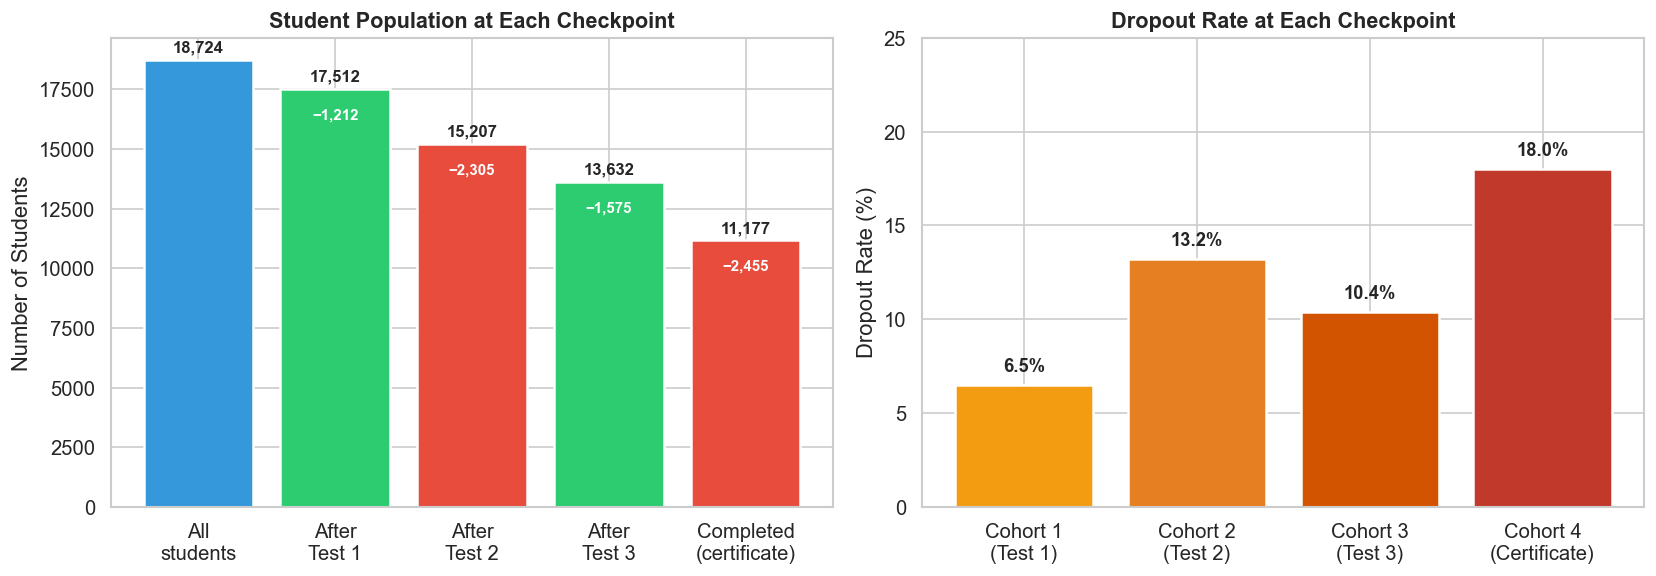


✓ Figure saved to outputs/figures/dropout_cascade.png


In [16]:
# ──────────────────────────────────────────────
# Plot 1: Dropout cascade, how the population shrinks
# ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: waterfall-style bar chart of cohort sizes
cohort_labels = ['All\nstudents', 'After\nTest 1', 'After\nTest 2', 'After\nTest 3', 'Completed\n(certificate)']
cohort_sizes  = [18724, 17512, 15207, 13632, 11177]
drops         = [0, 1212, 2305, 1575, 2455]

colors = ['#3498db'] + ['#2ecc71' if d < 2000 else '#e74c3c' for d in drops[1:]]

bars = axes[0].bar(cohort_labels, cohort_sizes, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Student Population at Each Checkpoint', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Students')
for bar, size, drop in zip(bars, cohort_sizes, drops):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{size:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    if drop > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 800,
                    f'−{drop:,}', ha='center', va='top', fontsize=9, color='white', fontweight='bold')

# Right: drop rate per cohort
cohort_nums = ['Cohort 1\n(Test 1)', 'Cohort 2\n(Test 2)', 'Cohort 3\n(Test 3)', 'Cohort 4\n(Certificate)']
drop_rates = [6.5, 13.2, 10.4, 18.0]

bars2 = axes[1].bar(cohort_nums, drop_rates, color=['#f39c12', '#e67e22', '#d35400', '#c0392b'],
                    edgecolor='white', linewidth=1.5)
axes[1].set_title('Dropout Rate at Each Checkpoint', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Dropout Rate (%)')
axes[1].set_ylim(0, 25)
for bar, rate in zip(bars2, drop_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{rate}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dropout_cascade.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to outputs/figures/dropout_cascade.png")

### Interpreting the dropout cascade

Two things stand out:

1. **Cohort 1 has the lowest dropout rate (6.5%)**: only 1,212 of 18,724 students leave after Test 1. These are likely the "tourist" dropouts: students who registered but never truly engaged. They're expected to be easy to predict because their behaviour (near-zero attendance, failing grades) is distinctive.

2. **Cohort 4 has the highest dropout rate (18.0%)**: 2,455 of 13,632 students who completed the *entire* course are still labelled as dropouts. These are the **administrative dropouts**: they attended every session, passed every test, and submitted all coursework, but didn't pay the final tuition instalment. Their behaviour is indistinguishable from completers, which means Cohort 4 models will likely struggle. This isn't a modelling failure: it's a data limitation (the financial signal was removed for GDPR compliance).

---
## 1.9: Saving the Cohort Datasets

We save each cohort in two formats:

- **With amortised engagement** → `cohort_N.parquet`
- **Without engagement features** → `cohort_N_noeng.parquet`

We use the **Parquet** file format (rather than CSV) because it preserves column data types exactly: no risk of integers being read back as floats, or needing to re-specify types when loading.

These eight files are the **handover** to Phase 2. From this point on, no other notebook will touch the raw CSV. All analysis will load these clean, validated, zero-missing-values cohort files.

In [17]:
# ──────────────────────────────────────────────
# Save all cohort datasets to Parquet
# ──────────────────────────────────────────────

for c_num in [1, 2, 3, 4]:
    # With engagement
    path_eng = PROCESSED_DIR / f'cohort_{c_num}.parquet'
    cohorts[c_num].to_parquet(path_eng, index=False)
    
    # Without engagement
    path_noeng = PROCESSED_DIR / f'cohort_{c_num}_noeng.parquet'
    cohorts_noeng[c_num].to_parquet(path_noeng, index=False)

print("✓ Saved cohort datasets to data/processed/:")
for c_num in [1, 2, 3, 4]:
    c_eng = cohorts[c_num]
    c_noeng = cohorts_noeng[c_num]
    print(f"  cohort_{c_num}.parquet        → {len(c_eng):>6,} rows × {len(c_eng.columns):>2} cols")
    print(f"  cohort_{c_num}_noeng.parquet   → {len(c_noeng):>6,} rows × {len(c_noeng.columns):>2} cols")

✓ Saved cohort datasets to data/processed/:
  cohort_1.parquet        → 18,724 rows ×  9 cols
  cohort_1_noeng.parquet   → 18,724 rows ×  6 cols
  cohort_2.parquet        → 17,512 rows × 12 cols
  cohort_2_noeng.parquet   → 17,512 rows ×  9 cols
  cohort_3.parquet        → 15,207 rows × 14 cols
  cohort_3_noeng.parquet   → 15,207 rows × 11 cols
  cohort_4.parquet        → 13,632 rows × 18 cols
  cohort_4_noeng.parquet   → 13,632 rows × 15 cols


We also save CSV copies of every cohort file for convenience: some tools and collaborators prefer CSV over Parquet. These go into a `csv/` subfolder inside `data/processed/` to keep things tidy.

In [18]:
# ──────────────────────────────────────────────
# Save CSV copies of all cohort datasets
# ──────────────────────────────────────────────

CSV_DIR = PROCESSED_DIR / 'csv'
CSV_DIR.mkdir(parents=True, exist_ok=True)

for c_num in [1, 2, 3, 4]:
    # With engagement
    cohorts[c_num].to_csv(CSV_DIR / f'cohort_{c_num}.csv', index=False)
    # Without engagement
    cohorts_noeng[c_num].to_csv(CSV_DIR / f'cohort_{c_num}_noeng.csv', index=False)

print(f'✓ CSV copies saved to {CSV_DIR}/:')
for f in sorted(CSV_DIR.iterdir()):
    print(f'  {f.name:<30} ({f.stat().st_size:>8,} bytes)')

✓ CSV copies saved to data/processed/csv/:
  cohort_1.csv                   ( 541,740 bytes)
  cohort_1_noeng.csv             ( 255,848 bytes)
  cohort_2.csv                   ( 734,136 bytes)
  cohort_2_noeng.csv             ( 481,803 bytes)
  cohort_3.csv                   ( 764,136 bytes)
  cohort_3_noeng.csv             ( 553,555 bytes)
  cohort_4.csv                   ( 902,213 bytes)
  cohort_4_noeng.csv             ( 727,174 bytes)


---
## 1.10: Final Summary Table

Let's produce a comprehensive summary of everything we've built, and save it as a CSV for reference.

In [19]:
# ──────────────────────────────────────────────
# Final summary table
# ──────────────────────────────────────────────

summary_rows = []

for c_num in [1, 2, 3, 4]:
    c_df = cohorts[c_num]
    target = TARGET_NAMES[c_num]
    n_features_eng = len(c_df.columns) - 1
    n_features_noeng = len(cohorts_noeng[c_num].columns) - 1
    n_survive = (c_df[target] == 1).sum()
    n_drop = (c_df[target] == 0).sum()
    drop_rate = n_drop / len(c_df) * 100
    
    summary_rows.append({
        'Cohort': c_num,
        'Checkpoint': ['After Test 1', 'After Test 2', 'After Test 3', 'Certificate'][c_num - 1],
        'Students': len(c_df),
        'Features (with eng.)': n_features_eng,
        'Features (no eng.)': n_features_noeng,
        'Survive': n_survive,
        'Drop': n_drop,
        'Drop Rate (%)': round(drop_rate, 1),
        'Missing Values': c_df.isnull().sum().sum(),
        'Target Column': target
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(TABLES_DIR / 'cohort_summary.csv', index=False)

print("Data Preparation Summary")
print("=" * 100)
print(summary_df.to_string(index=False))
print("\n✓ Summary saved to outputs/tables/cohort_summary.csv")

Data Preparation Summary
 Cohort   Checkpoint  Students  Features (with eng.)  Features (no eng.)  Survive  Drop  Drop Rate (%)  Missing Values           Target Column
      1 After Test 1     18724                     8                   5    17512  1212            6.5               0        survives_phase_1
      2 After Test 2     17512                    11                   8    15207  2305           13.2               0        survives_phase_2
      3 After Test 3     15207                    13                  10    13632  1575           10.4               0        survives_phase_3
      4  Certificate     13632                    17                  14    11177  2455           18.0               0 survives_to_certificate

✓ Summary saved to outputs/tables/cohort_summary.csv


---
## Summary: What We've Accomplished

### Key outcomes of this notebook:

1. **Loaded and validated** the raw dataset of 18,724 students across 18 features
2. **Confirmed the monotone missingness pattern**: missing values represent student exits, not data errors
3. **Encoded all categorical variables** using ordinal encoding (grades A=4→F=0, year first=1→third=3, external Y=1/N=0)
4. **Derived each student's lifespan** (1–4 cohorts) based on where their data ends
5. **Built four cohort datasets**, each with:
   - Only the students who reached that checkpoint
   - Only the features available at that point in the course
   - An engineered binary survival target
   - **Zero missing values**: no imputation needed or performed
6. **Amortised the engagement features** (forum Q, forum A, office hour visits) uniformly across each student's active cohorts, and also produced engagement-dropped variants for comparison
7. **Validated every count** against ground-truth numbers, with hard assertions that would have stopped execution if anything was wrong

### What's Next: Phase 2 Classification

Phase 2 will load these cohort files and train **five different classification models** on each cohort (a total of ~20 models) to predict which students will drop out at each checkpoint. We expect:

- **Simple linear models** (Logistic Regression) to perform well on early cohorts (many samples, few features)
- **Tree-based models** (Random Forest, Gradient Boosting) to perform well on late cohorts (more features, fewer samples)
- **Cohort 4 to be the hardest**: administrative dropouts behave identically to completers, so the model has no behavioural signal to work with

### Data integrity guarantee

> **No imputation was performed anywhere in this notebook.** Every missing value was handled by the cohort design itself: students who left are simply excluded from later cohorts, rather than having their missing data filled in with invented values. This is the methodologically correct approach for this dataset.